
# 03 — Retailrocket Behavior Analytics

**Product Pulse**

Behavioral analytics on the cleaned Retailrocket event stream:

- views → add-to-cart → transaction funnel
- visitor engagement
- item engagement and conversion
- repeat behavior
- daily event trends


In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.home() / "Desktop" / "resume_projects" / "ProductPulse"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "02_cleaned"

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)

if not PROCESSED_DIR.exists():
    raise FileNotFoundError(
        f"Processed data folder not found: {PROCESSED_DIR}\n"
        "Run 02_data_cleaning_and_validation.ipynb first."
    )


PROJECT_ROOT : /Users/noopur/Desktop/resume_projects/ProductPulse
PROCESSED_DIR: /Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/02_cleaned


In [2]:

EVENTS_PATH = PROCESSED_DIR / "retailrocket_events_clean.parquet"
if not EVENTS_PATH.exists():
    raise FileNotFoundError(EVENTS_PATH)

events = pd.read_parquet(EVENTS_PATH)
print("Shape:", events.shape)
print("Date range:", events["event_time"].min(), "→", events["event_time"].max())
display(events.head())


Shape: (2755641, 6)
Date range: 2015-05-03 03:00:04.384000+00:00 → 2015-09-18 02:59:47.788000+00:00


,timestamp,visitorid,event,itemid,transactionid,event_time
0,1433221332117,257597,view,355908,<NA>,2015-06-02 05:02:12.117000+00:00
1,1433224214164,992329,view,248676,<NA>,2015-06-02 05:50:14.164000+00:00
2,1433221999827,111016,view,318965,<NA>,2015-06-02 05:13:19.827000+00:00
3,1433221955914,483717,view,253185,<NA>,2015-06-02 05:12:35.914000+00:00
4,1433221337106,951259,view,367447,<NA>,2015-06-02 05:02:17.106000+00:00


## 1. Event overview

In [3]:

event_counts = events["event"].value_counts().rename_axis("event").reset_index(name="events")
event_counts["event_share_pct"] = (100 * event_counts["events"] / event_counts["events"].sum()).round(3)

overview = pd.DataFrame({
    "metric": ["events","unique_visitors","unique_items","transaction_events","date_start","date_end"],
    "value": [
        len(events), events["visitorid"].nunique(), events["itemid"].nunique(),
        int((events["event"] == "transaction").sum()),
        str(events["event_time"].min()), str(events["event_time"].max())
    ]
})
display(overview)
display(event_counts)


,metric,value
0,events,2755641
1,unique_visitors,1407580
2,unique_items,235061
3,transaction_events,22457
4,date_start,2015-05-03 03:00:04.384000+00:00
5,date_end,2015-09-18 02:59:47.788000+00:00


,event,events,event_share_pct
0,view,2664218,96.682
1,addtocart,68966,2.503
2,transaction,22457,0.815


## 2. Visitor funnel

In [4]:

visitor_flags = (
    events.assign(value=1)
    .pivot_table(index="visitorid", columns="event", values="value", aggfunc="max", fill_value=0)
    .reset_index()
)
for col in ["view","addtocart","transaction"]:
    if col not in visitor_flags.columns:
        visitor_flags[col] = 0

visitor_funnel = pd.DataFrame({
    "stage": ["Viewed","Added to cart","Transacted"],
    "unique_visitors": [
        int(visitor_flags["view"].sum()),
        int(visitor_flags["addtocart"].sum()),
        int(visitor_flags["transaction"].sum()),
    ]
})
viewer_count = visitor_funnel.loc[0,"unique_visitors"]
cart_count = visitor_funnel.loc[1,"unique_visitors"]
visitor_funnel["share_of_viewers_pct"] = (100 * visitor_funnel["unique_visitors"] / viewer_count).round(3)

funnel_metrics = pd.DataFrame({
    "metric": ["viewer_to_cart_pct","viewer_to_transaction_pct","cart_to_transaction_pct"],
    "value": [
        round(100*cart_count/viewer_count,3) if viewer_count else np.nan,
        round(100*visitor_funnel.loc[2,"unique_visitors"]/viewer_count,3) if viewer_count else np.nan,
        round(100*visitor_funnel.loc[2,"unique_visitors"]/cart_count,3) if cart_count else np.nan,
    ]
})
display(visitor_funnel)
display(funnel_metrics)


,stage,unique_visitors,share_of_viewers_pct
0,Viewed,1404179,100.000
1,Added to cart,37722,2.686
2,Transacted,11719,0.835


,metric,value
0,viewer_to_cart_pct,2.686
1,viewer_to_transaction_pct,0.835
2,cart_to_transaction_pct,31.067


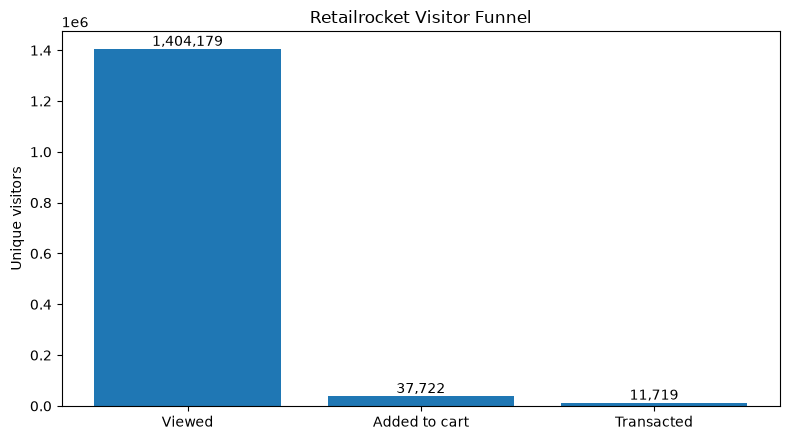

In [5]:

fig_funnel, ax = plt.subplots(figsize=(8,4.5))
ax.bar(visitor_funnel["stage"], visitor_funnel["unique_visitors"])
ax.set_title("Retailrocket Visitor Funnel")
ax.set_ylabel("Unique visitors")
for i,v in enumerate(visitor_funnel["unique_visitors"]):
    ax.text(i,v,f"{v:,}",ha="center",va="bottom")
fig_funnel.tight_layout(); plt.show()


## 3. Visitor engagement

In [6]:

visitor_summary = events.groupby("visitorid").agg(
    total_events=("event","size"), unique_items=("itemid","nunique"),
    first_event=("event_time","min"), last_event=("event_time","max")
).reset_index()
visitor_event_counts = events.groupby(["visitorid","event"]).size().unstack(fill_value=0).reset_index()
visitor_summary = visitor_summary.merge(visitor_event_counts,on="visitorid",how="left")
for col in ["view","addtocart","transaction"]:
    if col not in visitor_summary.columns:
        visitor_summary[col]=0
visitor_summary["active_days"] = (visitor_summary["last_event"].dt.normalize()-visitor_summary["first_event"].dt.normalize()).dt.days+1

engagement_summary = pd.DataFrame({
    "metric": ["median_events_per_visitor","mean_events_per_visitor","median_unique_items_per_visitor","visitors_with_2plus_events_pct","visitors_with_cart_pct","visitors_with_transaction_pct"],
    "value": [
        round(visitor_summary["total_events"].median(),3),
        round(visitor_summary["total_events"].mean(),3),
        round(visitor_summary["unique_items"].median(),3),
        round(100*(visitor_summary["total_events"]>=2).mean(),3),
        round(100*(visitor_summary["addtocart"]>0).mean(),3),
        round(100*(visitor_summary["transaction"]>0).mean(),3),
    ]
})
display(engagement_summary)


,metric,value
0,median_events_per_visitor,1.000
1,mean_events_per_visitor,1.958
2,median_unique_items_per_visitor,1.000
3,visitors_with_2plus_events_pct,28.843
4,visitors_with_cart_pct,2.680
5,visitors_with_transaction_pct,0.833


## 4. Item engagement

In [7]:

item_event_counts = events.groupby(["itemid","event"]).size().unstack(fill_value=0).reset_index()
for col in ["view","addtocart","transaction"]:
    if col not in item_event_counts.columns:
        item_event_counts[col]=0
item_visitors = events.groupby("itemid")["visitorid"].nunique().rename("unique_visitors").reset_index()
item_metrics = item_event_counts.merge(item_visitors,on="itemid",how="left")
item_metrics["cart_per_view_pct"] = np.where(item_metrics["view"]>0,100*item_metrics["addtocart"]/item_metrics["view"],np.nan)
item_metrics["transaction_per_view_pct"] = np.where(item_metrics["view"]>0,100*item_metrics["transaction"]/item_metrics["view"],np.nan)

top_items_by_transactions = item_metrics.sort_values(["transaction","addtocart","view"],ascending=False).head(20).copy()
top_items_by_views = item_metrics.sort_values("view",ascending=False).head(20).copy()
display(top_items_by_transactions)


,itemid,addtocart,transaction,view,unique_visitors,cart_per_view_pct,transaction_per_view_pct
232496,461686,304,133,2538,1393,11.977935,5.240347
60527,119736,44,97,752,267,5.851064,12.898936
107690,213834,17,92,293,258,5.802048,31.399317
157492,312728,161,46,947,615,17.001056,4.857445
3980,7943,97,46,1346,846,7.206538,3.417533
224330,445351,89,45,939,636,9.478168,4.792332
24339,48030,95,41,986,634,9.634888,4.158215
212061,420960,60,38,795,373,7.547170,4.779874
125146,248455,52,38,575,292,9.043478,6.608696
8763,17478,72,37,631,381,11.410460,5.863708


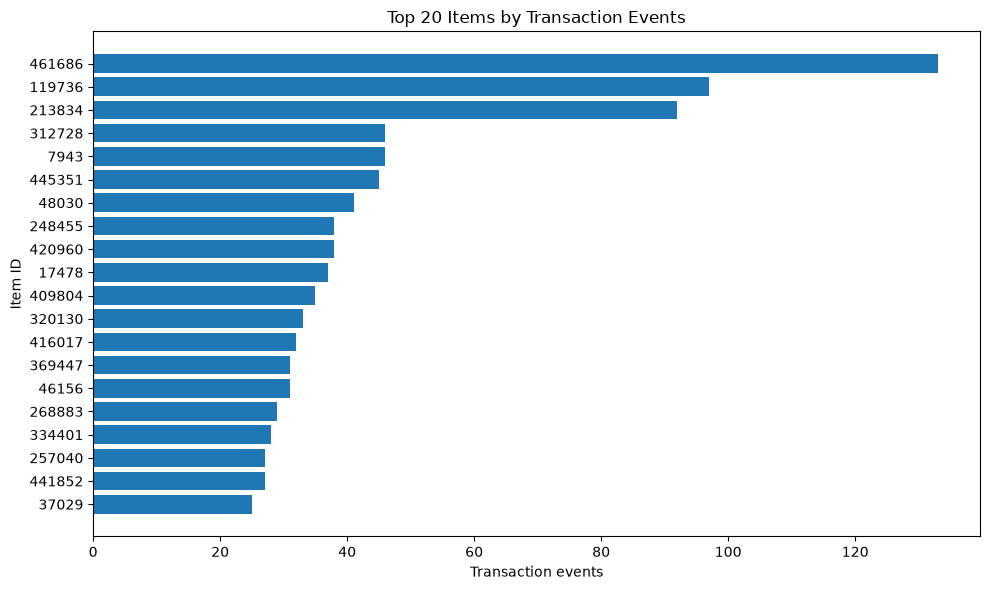

In [8]:

fig_items, ax = plt.subplots(figsize=(10,6))
plot_items = top_items_by_transactions.sort_values("transaction")
ax.barh(plot_items["itemid"].astype(str),plot_items["transaction"])
ax.set_title("Top 20 Items by Transaction Events")
ax.set_xlabel("Transaction events")
ax.set_ylabel("Item ID")
fig_items.tight_layout(); plt.show()


## 5. Daily behavior

In [9]:

events["event_date"] = events["event_time"].dt.floor("D")
daily_events = events.groupby(["event_date","event"]).size().unstack(fill_value=0).reset_index().sort_values("event_date")
for col in ["view","addtocart","transaction"]:
    if col not in daily_events.columns:
        daily_events[col]=0
display(daily_events.head())


event,event_date,addtocart,transaction,view
0,2015-05-03 00:00:00+00:00,296,83,13303
1,2015-05-04 00:00:00+00:00,578,154,18681
2,2015-05-05 00:00:00+00:00,561,225,22225
3,2015-05-06 00:00:00+00:00,647,258,23015
4,2015-05-07 00:00:00+00:00,572,217,22368


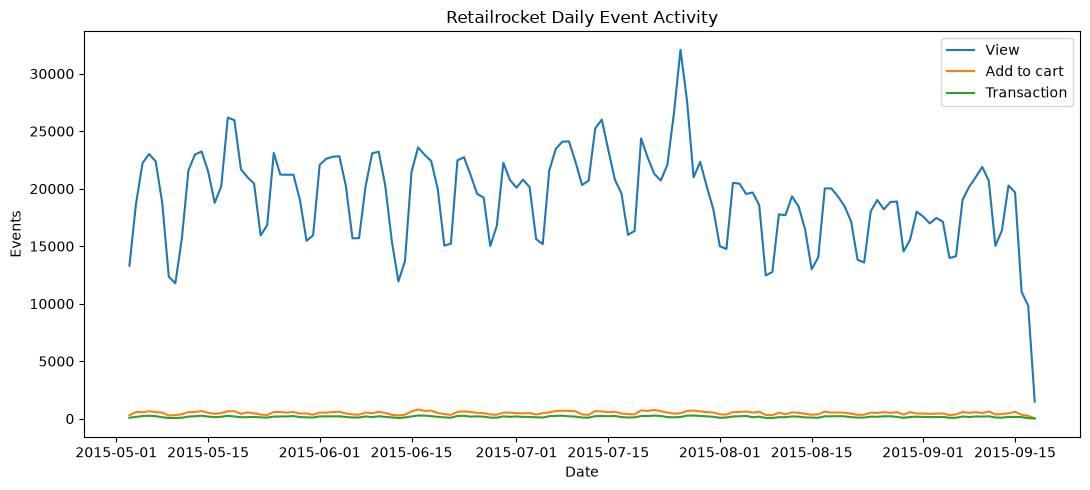

In [10]:

fig_daily, ax = plt.subplots(figsize=(11,5))
ax.plot(daily_events["event_date"],daily_events["view"],label="View")
ax.plot(daily_events["event_date"],daily_events["addtocart"],label="Add to cart")
ax.plot(daily_events["event_date"],daily_events["transaction"],label="Transaction")
ax.set_title("Retailrocket Daily Event Activity"); ax.set_xlabel("Date"); ax.set_ylabel("Events"); ax.legend()
fig_daily.tight_layout(); plt.show()


## 6. Save compact results

In [11]:

RESULTS_DIR = PROJECT_ROOT / "results" / "03_retailrocket_behavior_analytics"
TABLES_DIR = RESULTS_DIR / "tables"; FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR.mkdir(parents=True,exist_ok=True); FIGURES_DIR.mkdir(parents=True,exist_ok=True)
RESULT_TABLES = {
    "overview":overview,
    "event_counts":event_counts,
    "visitor_funnel":visitor_funnel,
    "funnel_metrics":funnel_metrics,
    "engagement_summary":engagement_summary,
    "top_items_by_transactions":top_items_by_transactions,
    "top_items_by_views":top_items_by_views,
    "daily_events":daily_events,
}
RESULT_FIGURES = {"visitor_funnel":fig_funnel,"top_items_by_transactions":fig_items,"daily_event_activity":fig_daily}
for name,table in RESULT_TABLES.items(): table.to_csv(TABLES_DIR/f"{name}.csv",index=False)
for name,fig in RESULT_FIGURES.items(): fig.savefig(FIGURES_DIR/f"{name}.png",dpi=200,bbox_inches="tight")
print(f"Tables saved : {len(RESULT_TABLES)}")
print(f"Figures saved: {len(RESULT_FIGURES)}")
print("Saved to:",RESULTS_DIR)


Tables saved : 8
Figures saved: 3
Saved to: /Users/noopur/Desktop/resume_projects/ProductPulse/results/03_retailrocket_behavior_analytics
